# CNN Classification Task with Cat-vs-Dog dataset
- **Dataset:** Microsoft Cats vs Dogs (~25,000 JPEG images)
- **Model:** 3-layer CNN with Dense head, Binary Cross-Entropy loss
- **Metrics:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix



In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

## data loaad

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
data_dir =os.path.join(path, 'PetImages')

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.


In [3]:
print(f'Dataset path: {data_dir}')
print(f'Classes found: {os.listdir(data_dir)}')

Dataset path: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages
Classes found: ['Dog', 'Cat']


##  Data Preprocessing

In [ ]:
# def safe_image_generator(generator):
#      while True:
#         try:
#             x, y = next(generator)
#             yield x, y
#         except (UnidentifiedImageError, OSError, Exception):
#             continue

In [4]:


IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

In [9]:
from PIL import Image
import os
import shutil


if os.path.exists("/kaggle/working/PetImages"):
    shutil.rmtree("/kaggle/working/PetImages")

shutil.copytree(data_dir, "/kaggle/working/PetImages")

data_dir = "/kaggle/working/PetImages"
def remove_corrupted_images(path):
    for root, dirs, files in os.walk(path):
        for file in files:
            try:
                img = Image.open(os.path.join(root, file))
                img.verify()
            except:
                os.remove(os.path.join(root, file))

remove_corrupted_images(data_dir)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


حذف الصور الخربانه قبل التدريب اخر النوت بوك كل لمصادر الي شفتها عشان احمل الداتا

In [10]:

train_data  = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)


val_data  = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

raw_train_dataset = train_data.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training', seed=42
)

raw_val_dataset = val_data.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation', seed=42
)

train_dataset = raw_train_dataset
val_dataset   = raw_val_dataset

print(f'Class indices: {raw_train_dataset.class_indices}')  # Cat=0, Dog=1
print(f'Training steps per epoch:   {len(raw_train_dataset)}')
print(f'Validation steps per epoch: {len(raw_val_dataset)}')

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}
Training steps per epoch:   625
Validation steps per epoch: 157


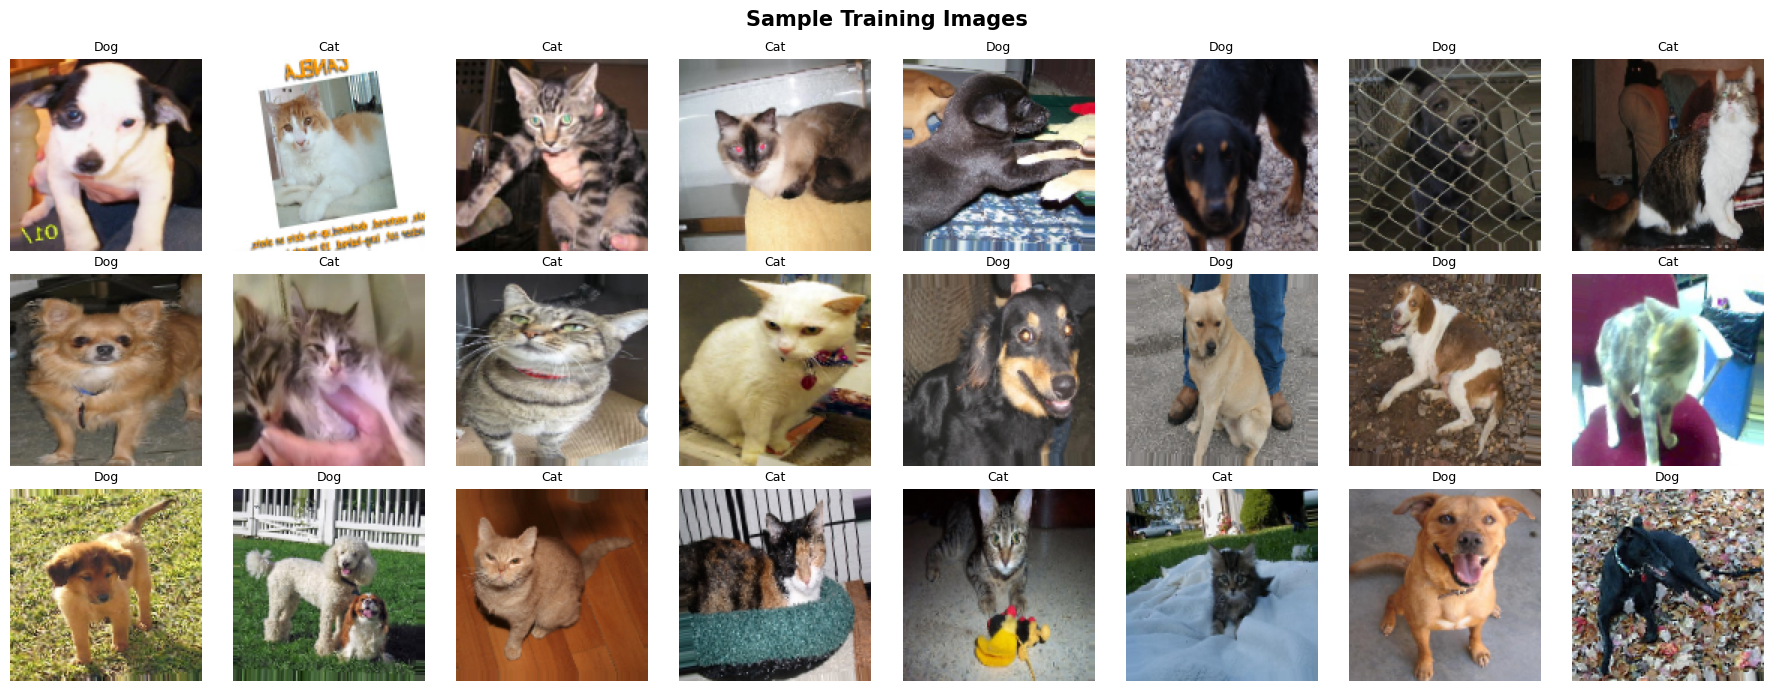

Image pixel range: [0.00, 1.00]
Batch shape: (32, 128, 128, 3)  |  Labels shape: (32,)


In [11]:
# Visualise a sample batch from the training set
sample_x, sample_y = next(train_dataset)
label_map = {0: 'Cat', 1: 'Dog'}

fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle('Sample Training Images', fontsize=15, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(sample_x):
        ax.imshow(sample_x[i])
        ax.set_title(label_map[int(sample_y[i])], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Image pixel range: [{sample_x.min():.2f}, {sample_x.max():.2f}]')
print(f'Batch shape: {sample_x.shape}  |  Labels shape: {sample_y.shape}')

In [ ]:
#
# IMG_SIZE = (128,128)
# BATCH_SIZE = 32

# train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
#     data_dir,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode="binary",
#     validation_split=0.2,
#     subset='training',
 # )

# val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
#     data_dir,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode="binary",
#     validation_split=0.2,
#     subset='validation',
 # )

In [ ]:
# model = models.Sequential([

#     layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
#     layers.MaxPooling2D((2,2)),

#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.MaxPooling2D((2,2)),

#     layers.Conv2D(128, (3,3), activation='relu'),
#     layers.MaxPooling2D((2,2)),

#     layers.Flatten(),

#     layers.Dense(128, activation='relu'),

#     layers.Dense(1, activation='sigmoid')
# ])

In [12]:

model = models.Sequential([

layers.Input(shape=(128,128,3)),

layers.Conv2D(32,(3,3),padding='same'),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.MaxPooling2D(),

layers.Conv2D(64,(3,3),padding='same'),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.MaxPooling2D(),

layers.Conv2D(128,(3,3),padding='same'),
layers.BatchNormalization(),
layers.Activation('relu'),
layers.MaxPooling2D(),

layers.Flatten(),

layers.Dense(128,activation='relu'),
layers.Dropout(0.5),

layers.Dense(1,activation='sigmoid')

])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,705 (16.36 MB)

 Trainable params: 4,288,257 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)
STEPS_PER_EPOCH  = len(raw_train_dataset)
VALIDATION_STEPS = len(raw_val_dataset)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    batch_size=64,

    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 183ms/step - accuracy: 0.5483 - loss: 1.4254 - val_accuracy: 0.5390 - val_loss: 0.6766
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.5815 - loss: 0.6514 - val_accuracy: 0.5992 - val_loss: 0.6110
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.6223 - loss: 0.6152 - val_accuracy: 0.5822 - val_loss: 0.6064
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.6811 - loss: 0.5805 - val_accuracy: 0.7511 - val_loss: 0.5080
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.6995 - loss: 0.5540 - val_accuracy: 0.8075 - val_loss: 0.4575
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.7206 - loss: 0.5342 - val_accuracy: 0.7919 - val_loss: 0.4448
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 122s 194ms/step - accuracy: 0.7302 - loss: 0.5158 - val_accuracy: 0.7985 - val_loss: 0.4352
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 185ms/step - accuracy: 0.7297 -

In [16]:

val_gen_eval = val_data.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation',
    shuffle=False, seed=42
)

y_true = val_gen_eval.classes


y_prob = model.predict(val_gen_eval, steps=len(val_gen_eval), verbose=1)
y_pred = (y_prob.flatten() >= 0.5).astype(int)



acc  = (y_true == y_pred).mean()
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)


print(f'Accuracy  :{acc:.4f} ')
print(f'Precision :{prec:.4f}')
print(f'Recall    :{rec:.4f}')
print(f'F1-Score  : {f1:.4f}')

print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

Found 4998 images belonging to 2 classes.
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step
Accuracy  :0.8639 
Precision :0.9084
Recall    :0.8095
F1-Score  : 0.8561
              precision    recall  f1-score   support

         Cat       0.83      0.92      0.87      2499
         Dog       0.91      0.81      0.86      2499

    accuracy                           0.86      4998
   macro avg       0.87      0.86      0.86      4998
weighted avg       0.87      0.86      0.86      4998



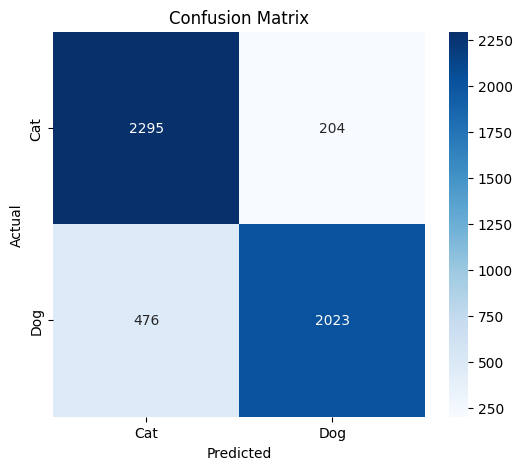

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat","Dog"],
            yticklabels=["Cat","Dog"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

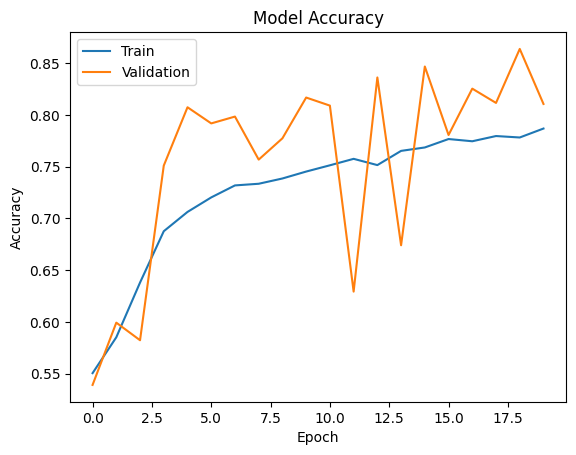

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

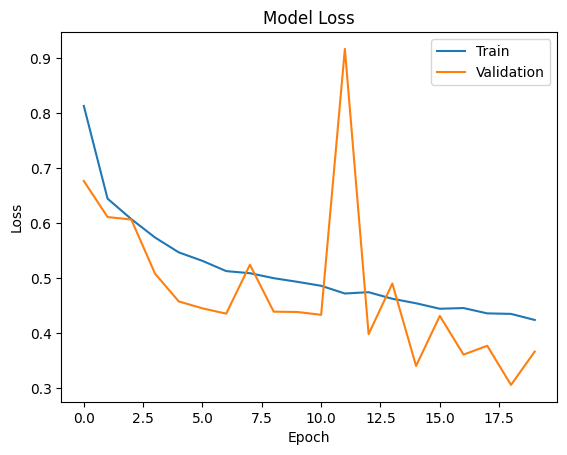

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

## References

The following Kaggle notebooks were consulted for guidance on loading
1. https://www.kaggle.com/code/uysimty/keras-cnn-dog-or-cat-classification



4. https://www.kaggle.com/code/prashant111/cnn-image-classification-cats-vs-dogs  
5. https://www.kaggle.com/code/chetankv/cnn-cats-vs-dogs-classification  
6. https://www.kaggle.com/code/uysimty/keras-cnn-dog-or-cat-classification